In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
#make a figures directory
import os
if not os.path.exists('figures'):
    os.makedirs('figures')

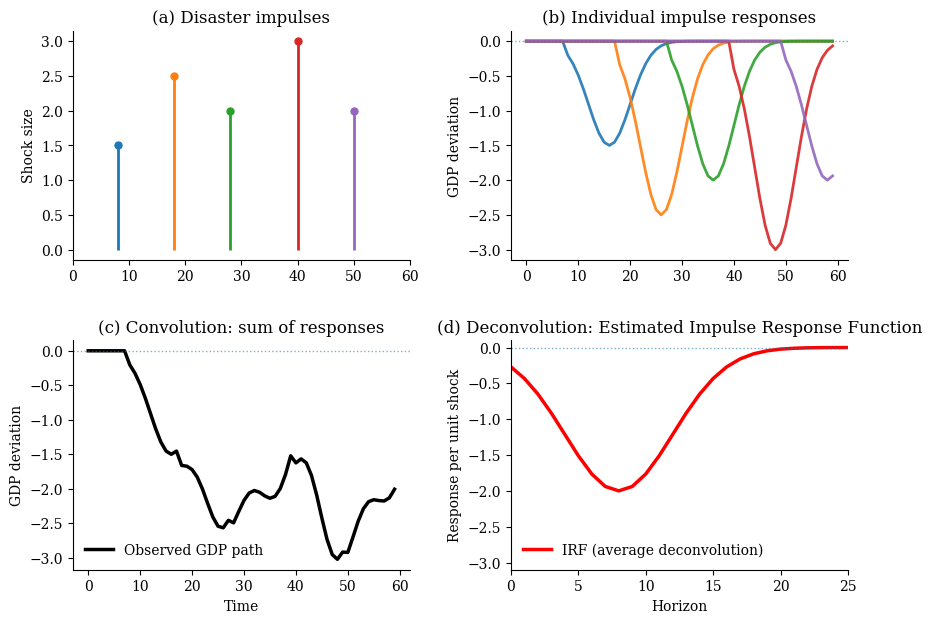

In [ ]:

T = 60
t = np.arange(T)

shock_times = [8, 18, 28, 40, 50]
shock_sizes = [1.5, 2.5, 2.0, 3.0, 2.0]

impulses = np.zeros(T)
for ti, si in zip(shock_times, shock_sizes):
    impulses[ti] = si


colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']


tau = np.arange(40)

def gaussian_irf(t, mu=8, sigma=4):
    return -np.exp(-(t - mu)**2 / (2 * sigma**2))

kernel = gaussian_irf(tau, mu=8, sigma=4)

# -----------------------------
# Individual IRFs from each shock
# -----------------------------
responses = []
for ti, si in zip(shock_times, shock_sizes):
    resp = np.zeros(T)
    r = si * kernel
    end = min(T - ti, len(r))
    resp[ti:ti+end] = r[:end]
    responses.append(resp)

responses = np.array(responses)

# Convolution (sum of all IRFs)
gdp_obs = np.sum(responses, axis=0)


# Compute individual IRFs (normalized by shock size)
aligned_responses = [
    resp[ti:ti+len(kernel)] / si
    for resp, si, ti in zip(responses, shock_sizes, shock_times)
]

# Find the longest IRF
max_len = max(len(a) for a in aligned_responses)

# Pad shorter IRFs with NaN
padded_responses = np.array([
    np.pad(a, (0, max_len - len(a)), constant_values=np.nan)
    for a in aligned_responses
])

# Compute mean IRF, ignoring NaNs
irf_est = np.nanmean(padded_responses, axis=0)*2

# Time axis
tau_est = np.arange(max_len)

# -----------------------------
# Plot
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False
})

fig, axes = plt.subplots(2, 2, figsize=(10, 7),
                         gridspec_kw={"hspace": 0.35, "wspace": 0.3})


ax = axes[0, 0]
for ti, si, c in zip(shock_times, shock_sizes, colors):
    ax.vlines(ti, 0, si, linewidth=2, color=c)
    ax.plot(ti, si, "o", color=c, markersize=5)

ax.set_xlim(0, T)
ax.set_ylabel("Shock size")
ax.set_title("(a) Disaster impulses")


ax = axes[0, 1]
for resp, c in zip(responses, colors):
    ax.plot(t, resp, linewidth=2, color=c, alpha=0.9)

ax.axhline(0, linestyle=":", linewidth=1, alpha=0.6)
ax.set_ylabel("GDP deviation")
ax.set_title("(b) Individual impulse responses")


ax = axes[1, 0]
ax.plot(t, gdp_obs, linewidth=2.5, color="black",
        label="Observed GDP path")

ax.axhline(0, linestyle=":", linewidth=1, alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("GDP deviation")
ax.set_title("(c) Convolution: sum of responses")
ax.legend(frameon=False)


ax = axes[1, 1]


# Estimated IRF
ax.plot(tau_est, irf_est, linewidth=2.5,
        color="red", label="IRF (average deconvolution)")


ax.axhline(0, linestyle=":", linewidth=1, alpha=0.6)
ax.set_xlabel("Horizon")
ax.set_ylabel("Response per unit shock")
#make y axis limit to match true irf
ax.set_ylim(-3.1, 0.1)
ax.set_xlim(0, 25)
ax.set_title("(d) Deconvolution: Estimated Impulse Response Function")
ax.legend(frameon=False, loc='best')

plt.savefig('figures/convolution_schema.png',
            bbox_inches='tight', dpi=300)
plt.show()


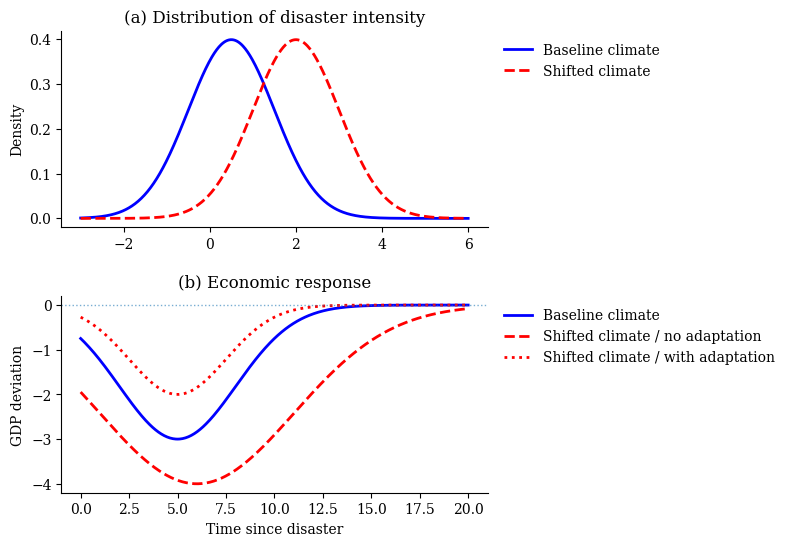

In [ ]:

# -----------------------------
# Densities
# -----------------------------
x = np.linspace(-3, 6, 500)

mu1, sigma1 = 0.5, 1.0   # baseline climate
mu2, sigma2 = 2.0, 1.0   # shifted climate

pdf1 = norm.pdf(x, mu1, sigma1)
pdf2 = norm.pdf(x, mu2, sigma2)

# -----------------------------
# Gaussian IRFs
# -----------------------------
t = np.linspace(0, 20, 400)

def gaussian_irf(t, A, mu, sigma):
    return -A * np.exp(-(t - mu)**2 / (2 * sigma**2))

# IRFs
irf_baseline = gaussian_irf(t, A=3.0, mu=5, sigma=3)          # blue
irf_shift_no_adapt = gaussian_irf(t, A=4.0, mu=6, sigma=5)    # red
irf_shift_adapt = gaussian_irf(t, A=2, mu=5, sigma=2.5)     # orange: milder than baseline


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False
})

fig, axes = plt.subplots(2, 1, figsize=(5.5, 6),
                         gridspec_kw={"hspace": 0.35})


ax = axes[0]
ax.plot(x, pdf1, linewidth=2, label="Baseline climate", color="blue")
ax.plot(x, pdf2, linewidth=2, linestyle="--", label="Shifted climate", color="red")
ax.set_ylabel("Density")
ax.set_title("(a) Distribution of disaster intensity")
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')


ax = axes[1]
ax.plot(t, irf_baseline, linewidth=2, label="Baseline climate", color="blue")
ax.plot(t, irf_shift_no_adapt, linewidth=2, linestyle="--", label="Shifted climate / no adaptation", color="red")
ax.plot(t, irf_shift_adapt, linewidth=2, linestyle=":", label="Shifted climate / with adaptation", color="red")

ax.axhline(0, linestyle=":", linewidth=1, alpha=0.6)
ax.set_xlabel("Time since disaster")
ax.set_ylabel("GDP deviation")
ax.set_title("(b) Economic response")
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
plt.savefig('figures/adapt_response_schema.png', bbox_inches='tight', dpi=300)

plt.show()


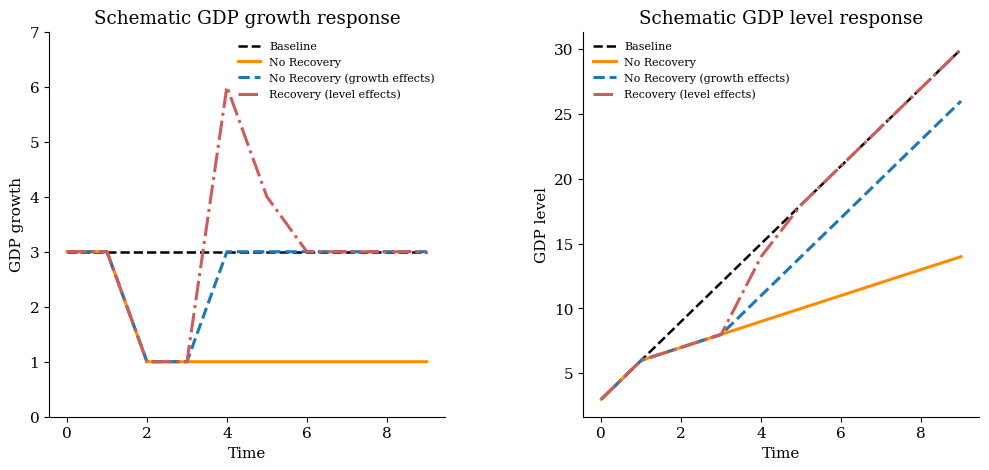

In [ ]:


t = np.arange(0, 10)

# Baseline growth
g_base = np.ones_like(t) * 3.0



g_norecover = np.array([3, 3, 1, 1, 1, 1, 1, 1, 1, 1])

g_trend = np.array([3, 3, 1, 1, 3, 3, 3, 3, 3, 3])

g_level = np.array([3, 3, 1, 1, 6, 4, 3, 3, 3, 3])



y_base = np.cumsum(g_base)

y_norecover = np.cumsum(g_norecover)
y_trend = np.cumsum(g_trend)
y_level = np.cumsum(g_level)

# -----------------------------
# Plot styling
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                         gridspec_kw={"wspace": 0.35})


ax = axes[0]

ax.plot(t, g_base, linestyle="--", linewidth=1.8, color="black", label="Baseline")

ax.plot(t, g_norecover, linewidth=2.2, color="darkorange", label="No Recovery")
ax.plot(t, g_trend, linestyle="--", linewidth=2.2, color="tab:blue", label="No Recovery (growth effects)")
ax.plot(t, g_level, linestyle="-.", linewidth=2.2, color="indianred", label="Recovery (level effects)")

ax.set_title("Schematic GDP growth response")
ax.set_xlabel("Time")
ax.set_ylabel("GDP growth")

ax.set_ylim(0, 7)
ax.legend(frameon=False, fontsize=8, loc="best")


ax = axes[1]

ax.plot(t, y_base, linestyle="--", linewidth=1.8, color="black", label="Baseline")

ax.plot(t, y_norecover, linewidth=2.2, color="darkorange", label="No Recovery")
ax.plot(t, y_trend, linestyle="--", linewidth=2.2, color="tab:blue", label="No Recovery (growth effects)")
ax.plot(t, y_level, linestyle="-.", linewidth=2.2, color="indianred", label="Recovery (level effects)")

ax.set_title("Schematic GDP level response")
ax.set_xlabel("Time")
ax.set_ylabel("GDP level")

ax.legend(frameon=False, fontsize=8, loc="best")

plt.savefig("figures/growth_level_recovery.png",
            bbox_inches="tight", dpi=300)
plt.show()


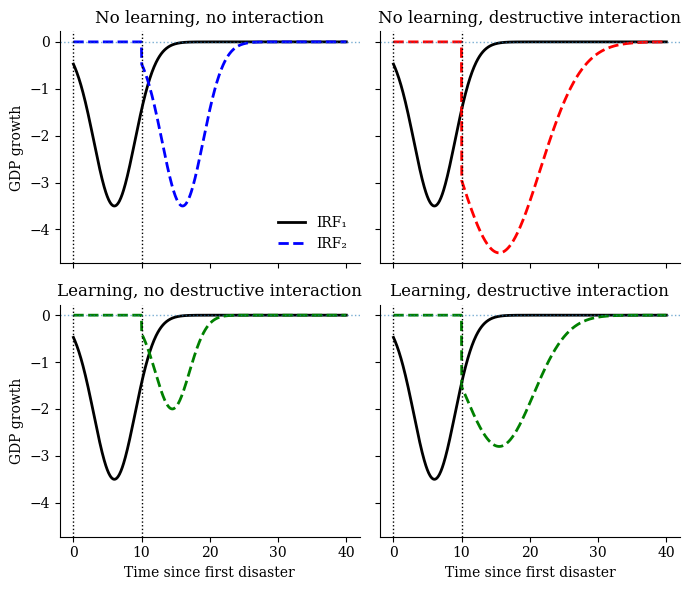

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


t = np.linspace(0, 40, 800)
T2 = 10  # timing of second disaster


def gaussian_irf(t, A, mu, sigma):
    return -A * np.exp(-(t - mu)**2 / (2 * sigma**2))


irf1 = gaussian_irf(t, A=3.5, mu=6, sigma=3)


irf2_no_learn_no_inter = gaussian_irf(t - T2, A=3.5, mu=6, sigma=3)
irf2_no_learn_destruct = gaussian_irf(t - T2, A=4.5, mu=5.5, sigma=6)
irf2_learn_no_inter    = gaussian_irf(t - T2, A=2.0, mu=4.5, sigma=2.5)
irf2_learn_destruct    = gaussian_irf(t - T2, A=2.8, mu=5.5, sigma=5)

for irf in [
    irf2_no_learn_no_inter,
    irf2_no_learn_destruct,
    irf2_learn_no_inter,
    irf2_learn_destruct
]:
    irf[t < T2] = 0


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False
})

fig, axes = plt.subplots(2, 2, figsize=(7, 6), sharex=True, sharey=True)
axes = axes.flatten()  # 🔑 KEY FIX

panels = [
    ("No learning, no interaction", irf2_no_learn_no_inter, "blue"),
    ("No learning, destructive interaction", irf2_no_learn_destruct, "red"),
    ("Learning, no destructive interaction", irf2_learn_no_inter, "green"),
    ("Learning, destructive interaction", irf2_learn_destruct, "green")
]

for ax, (title, irf2, color) in zip(axes, panels):
    ax.plot(t, irf1, color="black", linewidth=2, label="IRF₁")
    ax.plot(t, irf2, color=color, linewidth=2, linestyle="--", label="IRF₂")

    # Impulses
    ax.axvline(0, color="black", linestyle=":", linewidth=1)
    ax.axvline(T2, color="black", linestyle=":", linewidth=1)

    ax.axhline(0, linestyle=":", linewidth=1, alpha=0.6)
    ax.set_title(title)


axes[0].set_ylabel("GDP growth")
axes[2].set_ylabel("GDP growth")
axes[2].set_xlabel("Time since first disaster")
axes[3].set_xlabel("Time since first disaster")


axes[0].legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("figures/interaction_schema.png", bbox_inches="tight", dpi=300)
plt.show()


# IRF Estimaton

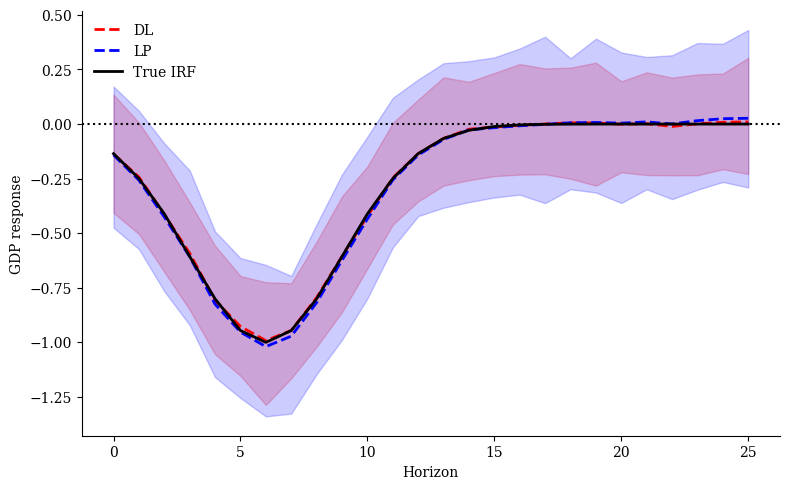

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

T = 200
H = 25
n_sim = 200
sigma = 0.5  # noise std

# Sparse shocks
s = np.zeros(T)
shock_times = [20, 60, 100, 140, 170]
shock_sizes = [1.5, 2.0, 1.0, 2.5, 1.8]
for t, a in zip(shock_times, shock_sizes):
    s[t] = a

# True IRF (flow)
tau = np.arange(H + 1)
true_irf = -np.exp(-(tau - 6)**2 / (2 * 3**2))

# Storage for simulated IRFs
dl_sims = np.zeros((n_sim, H + 1))
lp_sims = np.zeros((n_sim, H + 1))

# -----------------------------
# Simulation loop
# -----------------------------
for i in range(n_sim):

    # Generate GDP with noise
    y = np.zeros(T)
    for t in range(T):
        for h in range(min(H+1, t+1)):
            y[t] += true_irf[h] * s[t - h]
    y += np.random.normal(0, sigma, size=T)

    # --- DL estimation ---
    X_dl = np.column_stack([np.roll(s, h) for h in range(H+1)])
    valid = np.arange(T) >= H
    X_dl = sm.add_constant(X_dl[valid])
    #use first diff of y for DL to match LP's
    dy = np.diff(y, prepend=y[0])  
    y_dl = y[valid]
    res_dl = sm.OLS(y_dl, X_dl).fit()
    dl_sims[i] = res_dl.params[1:]
    #cumulate DL IRF to get flow response
    #dl_sims[i] = np.cumsum(dl_sims[i])

    # --- LP estimat
    beta_lp = np.zeros(H+1)

    for h in range(H+1):
        y_fwd = np.roll(y, -h)
        y_base = np.roll(y, 1)
        dy_cum = y_fwd - y_base

        # Valid indices
        valid_lp = (np.arange(T) >= 1) & (np.arange(T) < T - h)
        
        # Shock s_t
        s_t = s[valid_lp]
        
        # Lag of Δy
        dy_lag = dy[valid_lp]
        dy_lag = np.roll(dy_lag, 1)  # lag one period
        dy_lag[0] = 0               # first obs has no lag

        # Design matrix
        X_lp = np.column_stack([s_t])
        X_lp = sm.add_constant(X_lp)

        y_lp = dy_cum[valid_lp]

        res_lp = sm.OLS(y_lp, X_lp).fit()
        beta_lp[h] = res_lp.params[1]  # coefficient on s_t

    lp_sims[i] = beta_lp

dl_mean = dl_sims.mean(axis=0)
dl_lower = np.percentile(dl_sims, 2.5, axis=0)
dl_upper = np.percentile(dl_sims, 97.5, axis=0)

lp_mean = lp_sims.mean(axis=0)
lp_lower = np.percentile(lp_sims, 2.5, axis=0)
lp_upper = np.percentile(lp_sims, 97.5, axis=0)


plt.figure(figsize=(8,5))

# DL
plt.plot(dl_mean, "--", lw=2, c="red", label="DL")
plt.fill_between(np.arange(H+1), dl_lower, dl_upper, color="red", alpha=0.2)

plt.plot(lp_mean, "--", lw=2, c="blue", label="LP")
plt.fill_between(np.arange(H+1), lp_lower, lp_upper, color="blue", alpha=0.2)

# True IRF for reference
plt.plot(true_irf, lw=2, c="black", label="True IRF")

plt.axhline(0, ls=":", c="k")
plt.xlabel("Horizon")
plt.ylabel("GDP response")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()